
# Day 4 Lab: Failure-Risk Classification for Oil & Gas Equipment
### From Regression (Day 3) to Classification — Random Forest & XGBoost, Precision/Recall Evaluation, and Risk-Based Decision Rules

**Domain:** Upstream Production Operations — Electrical Submersible Pump (ESP) Fleet Reliability
**Business question:** *Which wells' ESPs are likely to fail in the next 30 days, and what should Operations do about it today?*

---

## Lab Objectives
By the end of this lab, you will be able to:
1. Frame a maintenance/reliability problem as a **binary classification** problem (Day 3 was regression → continuous target; today the target is *Yes/No, will it fail?*).
2. Engineer domain-driven features from raw sensor + operational data.
3. Train and compare **Random Forest** and **XGBoost** classifiers.
4. Evaluate models the *right* way for imbalanced, safety-critical problems — using **Precision, Recall, F1, ROC-AUC, PR-AUC** instead of relying on accuracy.
5. Convert a model's probability output into a **0–100 Risk Score**.
6. Translate risk scores into **business decision rules and alert tiers** (Low / Medium / High / Critical) that a field operations team can act on.
7. Package the whole thing into a reusable **end-to-end alert-generation function** — a mini production pipeline.

## Why this matters (SME note)
In Day 3, you built a **regression** model — e.g. predicting a continuous quantity such as remaining production rate or estimated time-to-failure. Regression answers *"how much / how long?"*.

Today's business question is different: *"Is this pump going to fail soon — yes or no — and how confident are we?"* That is a **classification** problem, and it is the single most common ML pattern in Oil & Gas reliability engineering: **predictive maintenance / failure-risk scoring** for ESPs, compressors, pumps, valves, and pipelines.

A classification model alone is not useful to a field engineer. What they need is a **decision**: *do I dispatch a crew today, next week, or not at all?* That is why this lab does not stop at model accuracy — it goes all the way to **actionable alerts**.



## Step 0 — Environment Setup

We import the libraries we need:
- `pandas` / `numpy` — data handling
- `matplotlib` / `seaborn` — visualization
- `scikit-learn` — Random Forest, preprocessing, train/test split, metrics
- `xgboost` — the XGBoost classifier
- `joblib` — saving the trained pipeline for later re-use (deployment)

> **Instructor note:** if `xgboost` is not installed in your environment, run `!pip install xgboost` in a cell first.


In [1]:

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, roc_curve, roc_auc_score, average_precision_score,
    f1_score, precision_score, recall_score
)
from xgboost import XGBClassifier
import joblib

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (7, 4.5)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries loaded successfully.")


Libraries loaded successfully.



## Step 1 — The Business Dataset: ESP Fleet Sensor & Operations Data

We simulate a realistic fleet of **6,000 Electrical Submersible Pump (ESP) records**, each representing one well's ESP system state at a monitoring snapshot. This mirrors data you would pull from a **SCADA / historian system** joined with **maintenance work-order history**.

| Feature | Description | Source system |
|---|---|---|
| `manufacturer` | ESP OEM | Asset register |
| `install_season` | Season the ESP was installed | Asset register |
| `pump_age_days` | Days since installation | Asset register |
| `run_hours_last_30d` | Operating hours in last 30 days | SCADA |
| `vibration_mm_s` | Vibration velocity (mm/s) | Downhole sensor |
| `vibration_trend_7d` | 7-day vibration trend (slope) | SCADA historian |
| `motor_temp_c` | Motor winding temperature (°C) | Downhole sensor |
| `temp_trend_7d` | 7-day temperature trend (slope) | SCADA historian |
| `intake_pressure_psi` / `discharge_pressure_psi` | Pump intake/discharge pressure | Downhole sensor |
| `motor_current_amp` | Motor current draw | SCADA |
| `power_factor` | Electrical power factor | SCADA |
| `insulation_resistance_mohm` | Motor winding insulation resistance | Electrical test log |
| `fluid_viscosity_cp` | Produced fluid viscosity | Lab/PVT |
| `sand_production_ppm` | Sand production rate | Production log |
| `gas_oil_ratio` | GOR | Production log |
| `well_depth_ft` | True vertical depth | Well file |
| `num_trips_last_year` | Workover/pulling trips in last 12 months | Maintenance history |
| `days_since_last_maint` | Days since last maintenance event | Maintenance history |
| `sensor_dropout_pct` | % of readings missing/flagged bad | Data quality |
| **`failure_within_30d`** | **Target: 1 if the ESP fails within 30 days, else 0** | Failure/trip log |

> **Instructor note:** in a real engagement you would build this table with a SQL join across the historian, the maintenance CMMS (e.g. SAP PM / Maximo) and the production database. The generation code below is only a realistic *stand-in* so everyone in the class works with an identical, reproducible dataset.


In [2]:

n = 6000

equipment_id = [f"ESP-{i:05d}" for i in range(n)]

pump_age_days = np.random.gamma(shape=2.2, scale=220, size=n).clip(5, 3000)
run_hours_last_30d = np.random.normal(650, 80, n).clip(0, 720)

vibration_mm_s = np.random.gamma(2.0, 1.1, n) + 0.002 * pump_age_days
motor_temp_c = np.random.normal(78, 9, n) + 0.004 * pump_age_days
intake_pressure_psi = np.random.normal(1450, 220, n)
discharge_pressure_psi = intake_pressure_psi + np.random.normal(900, 150, n)
motor_current_amp = np.random.normal(42, 6, n) + 0.01 * vibration_mm_s
fluid_viscosity_cp = np.random.gamma(2.5, 4.0, n)
sand_production_ppm = np.random.exponential(35, n)
gas_oil_ratio = np.random.normal(450, 120, n).clip(50, None)
num_trips_last_year = np.random.poisson(1.3, n)
days_since_last_maint = np.random.gamma(2.0, 60, n).clip(1, 900)
vibration_trend_7d = np.random.normal(0, 0.15, n) + 0.0006 * pump_age_days
temp_trend_7d = np.random.normal(0, 0.4, n) + 0.001 * pump_age_days
insulation_resistance_mohm = (np.random.gamma(6, 30, n) - 0.02 * pump_age_days).clip(5, None)
power_factor = np.random.normal(0.86, 0.05, n).clip(0.5, 0.99)
well_depth_ft = np.random.normal(9200, 1800, n).clip(2000, None)
sensor_dropout_pct = np.random.exponential(1.2, n).clip(0, 40)

manufacturer = np.random.choice(
    ['Baker Hughes', 'Schlumberger', 'Weatherford', 'ChampionX'], n, p=[0.32, 0.3, 0.2, 0.18]
)
install_season = np.random.choice(['Winter', 'Spring', 'Summer', 'Fall'], n)

df = pd.DataFrame({
    'equipment_id': equipment_id,
    'manufacturer': manufacturer,
    'install_season': install_season,
    'pump_age_days': pump_age_days,
    'run_hours_last_30d': run_hours_last_30d,
    'vibration_mm_s': vibration_mm_s,
    'vibration_trend_7d': vibration_trend_7d,
    'motor_temp_c': motor_temp_c,
    'temp_trend_7d': temp_trend_7d,
    'intake_pressure_psi': intake_pressure_psi,
    'discharge_pressure_psi': discharge_pressure_psi,
    'motor_current_amp': motor_current_amp,
    'power_factor': power_factor,
    'insulation_resistance_mohm': insulation_resistance_mohm,
    'fluid_viscosity_cp': fluid_viscosity_cp,
    'sand_production_ppm': sand_production_ppm,
    'gas_oil_ratio': gas_oil_ratio,
    'well_depth_ft': well_depth_ft,
    'num_trips_last_year': num_trips_last_year,
    'days_since_last_maint': days_since_last_maint,
    'sensor_dropout_pct': sensor_dropout_pct,
})

# ---------------------------------------------------------------
# Ground-truth failure generator (latent risk index -> probability -> label)
# This block plays the role of "real-world physics" and is normally
# NOT something you'd have in production -- there, failure_within_30d
# comes from historical failure/trip records, not a formula.
# ---------------------------------------------------------------
z = (
    0.035 * (df['vibration_mm_s'] - 2.0)
    + 0.9 * df['vibration_trend_7d']
    + 0.045 * (df['motor_temp_c'] - 80)
    + 0.6 * df['temp_trend_7d']
    - 0.02 * (df['insulation_resistance_mohm'] - 150) / 10
    + 0.012 * (df['sand_production_ppm'] - 30) / 10
    + 0.0009 * (df['pump_age_days'] - 400)
    + 0.006 * (df['days_since_last_maint'] - 150) / 10
    - 0.15 * (df['power_factor'] - 0.86) * 10
    + 0.05 * df['num_trips_last_year']
    + 0.02 * df['sensor_dropout_pct']
    + np.random.normal(0, 0.35, n)
)
true_prob = 1 / (1 + np.exp(-(z - 1.7)))
df['failure_within_30d'] = np.random.binomial(1, true_prob)

print("Dataset shape:", df.shape)
print("\nClass balance (target = failure_within_30d):")
print(df['failure_within_30d'].value_counts(normalize=True).rename("proportion"))
df.head()


Dataset shape: (6000, 22)

Class balance (target = failure_within_30d):
failure_within_30d
0    0.698
1    0.302
Name: proportion, dtype: float64


,equipment_id,manufacturer,install_season,pump_age_days,run_hours_last_30d,vibration_mm_s,vibration_trend_7d,motor_temp_c,temp_trend_7d,intake_pressure_psi,...,power_factor,insulation_resistance_mohm,fluid_viscosity_cp,sand_production_ppm,gas_oil_ratio,well_depth_ft,num_trips_last_year,days_since_last_maint,sensor_dropout_pct,failure_within_30d
0,ESP-00000,Schlumberger,Winter,578.791669,529.156316,4.622610,0.260049,91.412626,0.513426,951.518951,...,0.990000,174.314955,11.918261,92.836778,406.695658,8965.343443,1,161.574107,2.371628,0
1,ESP-00001,Baker Hughes,Spring,370.493718,594.977256,5.018997,0.006415,75.594012,0.209525,1097.183613,...,0.806195,80.258210,6.642176,23.198305,472.573370,8662.911912,2,439.693025,1.290910,0
2,ESP-00002,Weatherford,Spring,344.229637,595.839106,3.112067,0.114215,91.076618,0.519313,1739.841983,...,0.771942,141.155629,3.841309,147.437941,313.125741,8128.613302,1,217.462654,2.545585,1
3,ESP-00003,Baker Hughes,Winter,344.234024,620.048797,2.227981,0.126268,85.265155,0.554169,1163.618208,...,0.890230,400.953739,5.308448,21.115550,391.286266,7324.866126,1,13.496042,1.683572,0
4,ESP-00004,ChampionX,Fall,1091.717110,575.878940,3.373676,0.836448,80.739134,1.204256,1473.776197,...,0.840806,318.204026,4.797477,31.273664,518.397262,9647.363014,2,138.866319,0.042752,1



### Explanation of the logic
- We simulate each sensor/operational variable with a distribution that mimics real ESP telemetry (e.g. `vibration_mm_s` uses a Gamma distribution because vibration readings are right-skewed and non-negative).
- We then build a **latent risk index `z`** — a weighted combination of the variables that *actually drive* ESP failure in the field (rising vibration trend, high temperature trend, low insulation resistance, high sand production, pump age, overdue maintenance, poor power factor). This is exactly the kind of relationship a real model will have to *discover* from historical data — we are only using it here to generate a labeled dataset for the class.
- We pass `z` through a **sigmoid function** to turn it into a probability (`true_prob`), then draw the binary label `failure_within_30d` from a Bernoulli/binomial distribution. This is the standard way to simulate realistic classification data: **latent score → probability → 0/1 draw** — never assign labels deterministically, because real-world failure is never 100% predictable from sensor data alone.
- The resulting class balance (~30% failures) is a realistic **moderate imbalance** — common in predictive maintenance, and enough to require the special evaluation care in Step 5.


In [3]:

# Save a copy so the dataset can be reused outside this notebook (e.g. Day 5)
df.to_csv("esp_failure_data.csv", index=False)
df.describe().T.round(2)


,count,mean,std,min,25%,50%,75%,max
pump_age_days,6000.0,487.38,323.52,5.00,252.54,414.95,649.42,3000.00
run_hours_last_30d,6000.0,642.46,67.26,359.18,596.94,651.41,705.50,720.00
vibration_mm_s,6000.0,3.18,1.69,0.29,1.94,2.87,4.06,15.58
vibration_trend_7d,6000.0,0.29,0.25,-0.46,0.12,0.27,0.43,1.81
motor_temp_c,6000.0,80.06,9.08,41.71,74.03,79.96,86.25,118.96
temp_trend_7d,6000.0,0.49,0.52,-1.34,0.14,0.46,0.81,3.02
intake_pressure_psi,6000.0,1446.14,217.44,746.68,1295.66,1443.35,1593.79,2395.75
discharge_pressure_psi,6000.0,2349.16,263.41,1374.66,2173.56,2345.13,2529.83,3376.92
motor_current_amp,6000.0,42.02,5.96,21.72,37.99,41.99,45.98,61.21
power_factor,6000.0,0.86,0.05,0.67,0.83,0.86,0.89,0.99



## Step 2 — Exploratory Data Analysis (EDA)

Before modeling, always check:
1. **Class balance** of the target (drives our choice of metrics and model settings).
2. **Distributions** of key sensor variables, split by failure outcome (do failed units really look different?).
3. **Correlations** among numeric features (helps catch redundant features / multicollinearity).


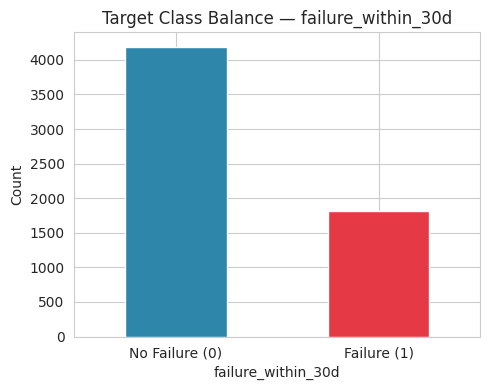

failure_within_30d
0    4188
1    1812
Name: count, dtype: int64


In [4]:

fig, ax = plt.subplots(1, 1, figsize=(5, 4))
df['failure_within_30d'].value_counts().plot(kind='bar', color=['#2E86AB', '#E63946'], ax=ax)
ax.set_xticklabels(['No Failure (0)', 'Failure (1)'], rotation=0)
ax.set_ylabel("Count")
ax.set_title("Target Class Balance — failure_within_30d")
plt.tight_layout()
plt.show()

print(df['failure_within_30d'].value_counts())


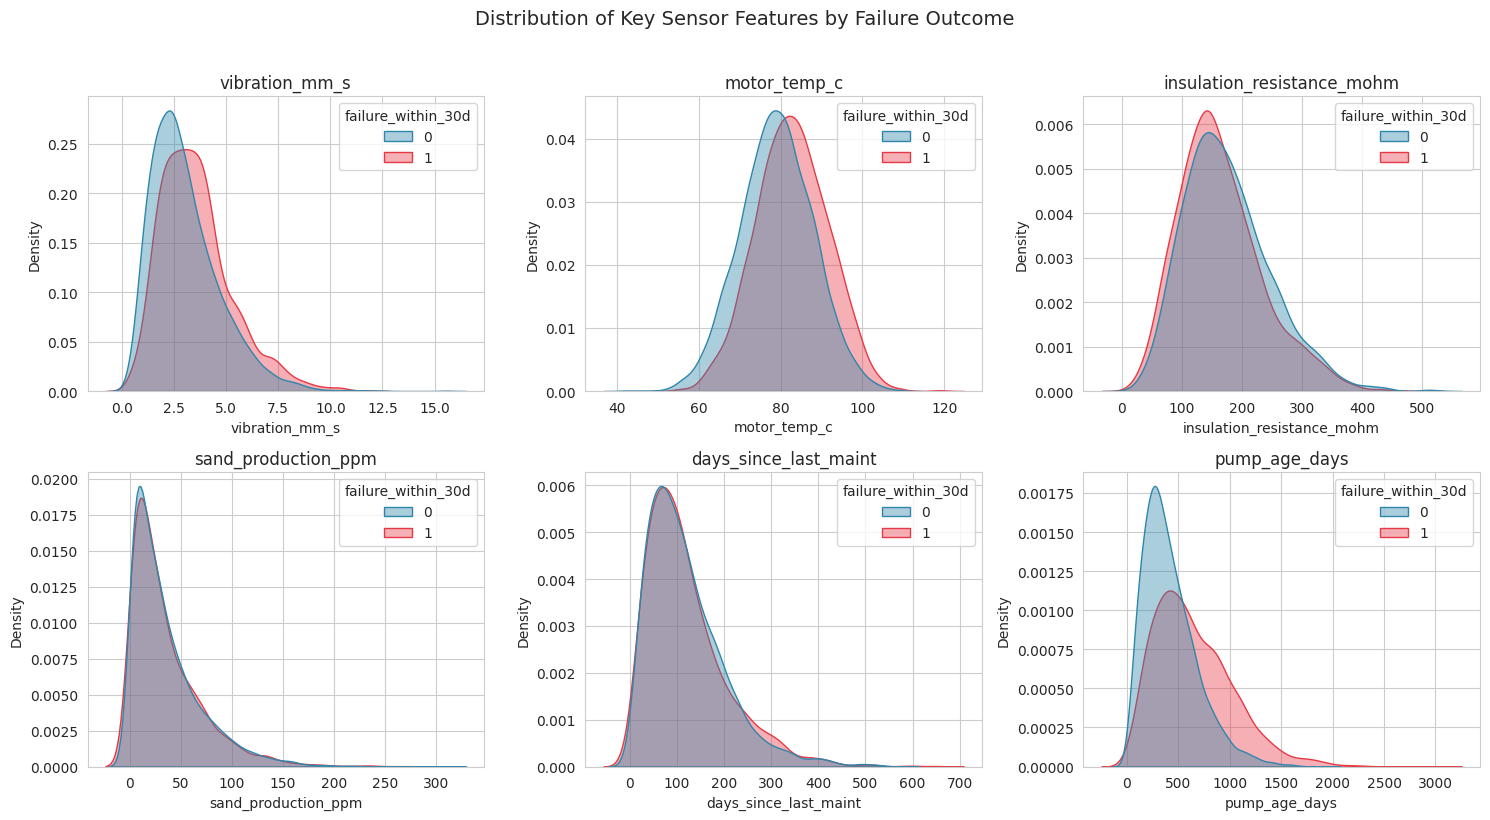

In [5]:

key_vars = ['vibration_mm_s', 'motor_temp_c', 'insulation_resistance_mohm',
            'sand_production_ppm', 'days_since_last_maint', 'pump_age_days']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), key_vars):
    sns.kdeplot(data=df, x=col, hue='failure_within_30d', fill=True,
                common_norm=False, alpha=0.4, ax=ax, palette=['#2E86AB', '#E63946'])
    ax.set_title(col)
plt.suptitle("Distribution of Key Sensor Features by Failure Outcome", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()



### Explanation of the logic
- The **bar chart** confirms the target is *imbalanced* (roughly 70/30). This single fact changes everything downstream: plain **accuracy** would be a misleading metric (a model that always predicts "no failure" would already score ~70% accuracy while catching **zero** real failures), and it justifies the `class_weight` / `scale_pos_weight` settings we use in Step 4.
- The **KDE (density) plots** let us visually sanity-check the engineered signal: failed units (red) should skew toward higher vibration, higher temperature, lower insulation resistance, higher sand production, longer time since maintenance, and higher age. If the two distributions were identical, the feature would carry no predictive signal.


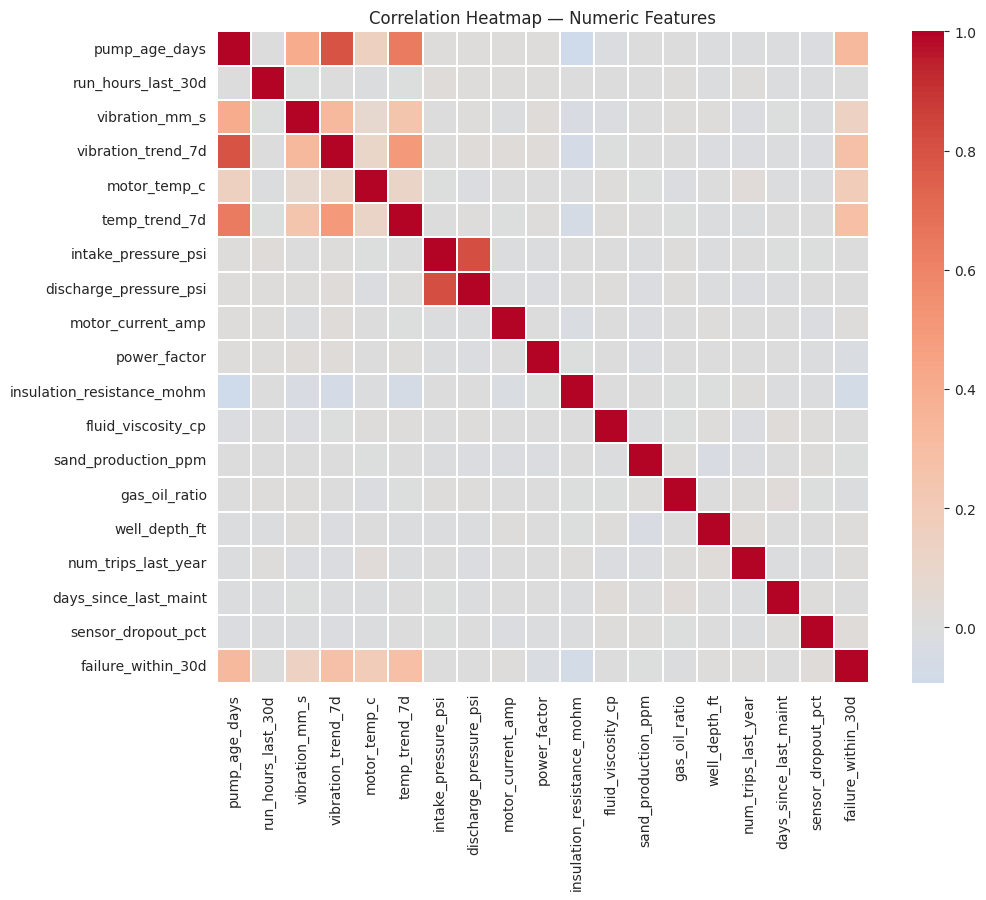

failure_within_30d            1.000000
pump_age_days                 0.321024
temp_trend_7d                 0.282321
vibration_trend_7d            0.274733
motor_temp_c                  0.193788
vibration_mm_s                0.142356
sensor_dropout_pct            0.018246
well_depth_ft                 0.014149
motor_current_amp             0.012355
num_trips_last_year           0.010484
days_since_last_maint         0.005363
fluid_viscosity_cp            0.002922
discharge_pressure_psi        0.002561
intake_pressure_psi           0.002303
run_hours_last_30d            0.000754
sand_production_ppm          -0.002637
gas_oil_ratio                -0.007157
power_factor                 -0.029741
insulation_resistance_mohm   -0.072428
Name: failure_within_30d, dtype: float64

In [6]:

plt.figure(figsize=(11, 9))
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, square=True, linewidths=0.3)
plt.title("Correlation Heatmap — Numeric Features")
plt.tight_layout()
plt.show()

corr['failure_within_30d'].sort_values(ascending=False)



### Explanation of the logic
The correlation heatmap and the sorted correlation-with-target list tell us **which raw features already carry the strongest linear signal** toward failure (e.g. `vibration_trend_7d`, `temp_trend_7d`, `days_since_last_maint`). Tree-based models like Random Forest/XGBoost can capture non-linear and interaction effects too, so a weak *linear* correlation does not mean a feature is useless — but strong correlations here are a good early confirmation that our engineered features (next step) are pointed in the right direction.



## Step 3 — Domain-Driven Feature Engineering

Raw sensor values are useful, but **engineered features that encode domain knowledge** almost always improve a reliability model. We create:

| New feature | Formula | Why it matters |
|---|---|---|
| `pressure_diff_psi` | discharge − intake pressure | A shrinking differential often signals pump wear or gas interference |
| `temp_per_age` | motor_temp_c / (pump_age_days + 1) | Normalizes temperature by unit age — an old unit running hot is different from a new one running hot |
| `vibration_x_trend` | vibration × (1 + 7-day trend) | Combines current severity *and* direction of change — a rising vibration trend is a stronger early-warning signal than a high but stable vibration |
| `maint_overdue_ratio` | days_since_last_maint / (pump_age_days + 1) | Captures how "overdue" a unit is relative to its own service life |
| `load_factor` | run_hours_last_30d / 720 | % utilization in the period — highly loaded units fail differently than idle ones |
| `insulation_per_age` | insulation_resistance / (pump_age_days + 1) | Normalizes electrical health by age |

This mirrors what you did in **Day 3** (ratios, ratios-over-time, normalization) — the *techniques* transfer directly from regression to classification; only the target and evaluation approach change.


In [7]:

df_fe = df.copy()

df_fe['pressure_diff_psi']   = df_fe['discharge_pressure_psi'] - df_fe['intake_pressure_psi']
df_fe['temp_per_age']        = df_fe['motor_temp_c'] / (df_fe['pump_age_days'] + 1)
df_fe['vibration_x_trend']   = df_fe['vibration_mm_s'] * (1 + df_fe['vibration_trend_7d'].clip(lower=-0.9))
df_fe['maint_overdue_ratio'] = df_fe['days_since_last_maint'] / (df_fe['pump_age_days'] + 1)
df_fe['load_factor']         = df_fe['run_hours_last_30d'] / 720.0
df_fe['insulation_per_age']  = df_fe['insulation_resistance_mohm'] / (df_fe['pump_age_days'] + 1)

new_feats = ['pressure_diff_psi', 'temp_per_age', 'vibration_x_trend',
             'maint_overdue_ratio', 'load_factor', 'insulation_per_age']
df_fe[new_feats].describe().T.round(3)


,count,mean,std,min,25%,50%,75%,max
pressure_diff_psi,6000.0,903.011,151.233,340.220,799.310,903.058,1005.927,1420.555
temp_per_age,6000.0,0.290,0.435,0.031,0.122,0.190,0.314,14.086
vibration_x_trend,6000.0,4.233,2.695,0.229,2.324,3.599,5.467,21.044
maint_overdue_ratio,6000.0,0.438,0.936,0.002,0.121,0.238,0.478,44.938
load_factor,6000.0,0.892,0.093,0.499,0.829,0.905,0.980,1.000
insulation_per_age,6000.0,0.647,1.149,0.005,0.221,0.386,0.718,45.855



## Step 4 — Train/Test Split & Preprocessing Pipeline

Key decisions here, explained:

1. **Stratified split** (`stratify=y`): because the target is imbalanced (~30% positive), a plain random split could accidentally under- or over-represent failures in the test set. `stratify=y` forces the same ~30/70 ratio in both train and test sets, giving a fair evaluation.
2. **`ColumnTransformer` + `OneHotEncoder`**: categorical columns (`manufacturer`, `install_season`) are one-hot encoded; numeric columns pass through unchanged. Wrapping this in a **Pipeline** with the model guarantees the *exact same* transformation is applied consistently to train, test, and any future/live data — this is what makes a notebook pipeline deployment-ready.
3. We **exclude `equipment_id`** — it's an identifier, not a predictive feature (including it would let the model "memorize" the training set instead of learning generalizable patterns).


In [8]:

target = 'failure_within_30d'
drop_cols = ['equipment_id', target]

X = df_fe.drop(columns=drop_cols)
y = df_fe[target]

cat_cols = ['manufacturer', 'install_season']
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=RANDOM_STATE
)

print("Train shape:", X_train.shape, " | Failure rate:", round(y_train.mean(), 3))
print("Test shape: ", X_test.shape,  " | Failure rate:", round(y_test.mean(), 3))

preprocessor = ColumnTransformer(
    transformers=[('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)],
    remainder='passthrough'
)


Train shape: (4500, 26)  | Failure rate: 0.302
Test shape:  (1500, 26)  | Failure rate: 0.302



## Step 5 — Model 1: Random Forest Classifier

**Why Random Forest for this problem?**
- Handles a mix of numeric + one-hot categorical features without needing feature scaling.
- Robust to outliers and non-linear relationships (common in sensor data).
- `class_weight='balanced_subsample'` automatically up-weights the minority class (failures) in every bootstrap sample, so the model doesn't just learn to predict "no failure" for everything.
- Gives us free **feature importances** for explainability — critical when you need to justify a maintenance dispatch decision to an operations manager.

**Key hyperparameters explained:**
- `n_estimators=400` — number of trees; more trees stabilize predictions (diminishing returns beyond a point).
- `max_depth=8`, `min_samples_leaf=15` — control tree complexity to reduce overfitting on noisy sensor data.
- `random_state=42` — reproducibility.


In [9]:

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=400,
        max_depth=8,
        min_samples_leaf=15,
        class_weight='balanced_subsample',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_pipeline.fit(X_train, y_train)
rf_proba = rf_pipeline.predict_proba(X_test)[:, 1]
rf_pred_default = (rf_proba >= 0.5).astype(int)

print("Random Forest trained.")
print("Sample predicted probabilities:", np.round(rf_proba[:10], 3))


Random Forest trained.
Sample predicted probabilities: [0.514 0.328 0.524 0.387 0.345 0.27  0.483 0.274 0.251 0.244]



## Step 6 — Model 2: XGBoost Classifier

**Why XGBoost as the second technique?**
- Builds trees **sequentially**, each one correcting the errors of the previous ones (gradient boosting) — often squeezes out more predictive performance than a Random Forest on tabular/sensor data.
- `scale_pos_weight` is XGBoost's equivalent of `class_weight` — it tells the algorithm how much more to penalize missing a failure vs. a false alarm. We compute it as `(negative count) / (positive count)` in the **training set only** (never using test data to avoid leakage).
- `subsample=0.8`, `colsample_bytree=0.8` — each tree only sees 80% of rows/columns, which reduces overfitting (similar in spirit to Random Forest's bagging).
- `learning_rate=0.05` with `n_estimators=300` — a smaller learning rate with more trees usually generalizes better than a large learning rate with few trees.


In [10]:

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight (neg/pos ratio in training set):", round(scale_pos_weight, 3))

xgb_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=scale_pos_weight,
        eval_metric='logloss',
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgb_pipeline.fit(X_train, y_train)
xgb_proba = xgb_pipeline.predict_proba(X_test)[:, 1]
xgb_pred_default = (xgb_proba >= 0.5).astype(int)

print("XGBoost trained.")
print("Sample predicted probabilities:", np.round(xgb_proba[:10], 3))


scale_pos_weight (neg/pos ratio in training set): 2.311


XGBoost trained.
Sample predicted probabilities: [0.471 0.329 0.477 0.398 0.276 0.156 0.306 0.535 0.187 0.086]



## Step 7 — Evaluation: Precision, Recall, F1, ROC-AUC, PR-AUC

### Why not just use accuracy?
With ~30% failures, a lazy model that predicts "no failure" every time scores **~70% accuracy** while catching **0 real failures** — useless, and dangerous, for a reliability program. We need metrics that focus on how well the model finds the failures:

| Metric | Formula (plain language) | Business meaning here |
|---|---|---|
| **Precision** | Of all units we *flagged* as high risk, what % actually failed? | How much we trust an alert — low precision = crews chasing false alarms |
| **Recall** | Of all units that *actually* failed, what % did we catch? | How safe we are — low recall = missed failures, unplanned downtime |
| **F1-score** | Harmonic mean of precision & recall | Single number balancing both, useful for comparing models |
| **ROC-AUC** | Ability to rank a random failure above a random non-failure | Overall discrimination ability, threshold-independent |
| **PR-AUC (Average Precision)** | Area under the precision-recall curve | More informative than ROC-AUC on imbalanced data |

In predictive maintenance, **missing a real failure (a False Negative) is usually more costly** than a false alarm (a False Positive) — an unplanned ESP failure means deferred production plus an expensive emergency workover, while a false alarm only costs an unnecessary inspection trip. This is *why* we bias the models toward **recall** using `class_weight` / `scale_pos_weight`, and why we will tune the decision threshold with recall in mind (Step 9).


In [11]:

def evaluate_model(name, y_true, proba, threshold=0.5):
    pred = (proba >= threshold).astype(int)
    print(f"\n=== {name}  (threshold = {threshold}) ===")
    print(classification_report(y_true, pred, digits=3, target_names=['No Failure', 'Failure']))
    print("ROC-AUC :", round(roc_auc_score(y_true, proba), 3))
    print("PR-AUC  :", round(average_precision_score(y_true, proba), 3))
    return {
        'model': name,
        'precision': precision_score(y_true, pred),
        'recall': recall_score(y_true, pred),
        'f1': f1_score(y_true, pred),
        'roc_auc': roc_auc_score(y_true, proba),
        'pr_auc': average_precision_score(y_true, proba)
    }

results = []
results.append(evaluate_model("Random Forest", y_test, rf_proba))
results.append(evaluate_model("XGBoost", y_test, xgb_proba))

results_df = pd.DataFrame(results).set_index('model').round(3)
results_df



=== Random Forest  (threshold = 0.5) ===
              precision    recall  f1-score   support

  No Failure      0.796     0.766     0.781      1047
     Failure      0.503     0.547     0.524       453

    accuracy                          0.700      1500
   macro avg      0.650     0.657     0.653      1500
weighted avg      0.708     0.700     0.703      1500

ROC-AUC : 0.715
PR-AUC  : 0.545

=== XGBoost  (threshold = 0.5) ===
              precision    recall  f1-score   support

  No Failure      0.795     0.725     0.758      1047
     Failure      0.472     0.567     0.515       453

    accuracy                          0.677      1500
   macro avg      0.633     0.646     0.637      1500
weighted avg      0.697     0.677     0.685      1500

ROC-AUC : 0.704
PR-AUC  : 0.524


,precision,recall,f1,roc_auc,pr_auc
model,,,,,
Random Forest,0.503,0.547,0.524,0.715,0.545
XGBoost,0.472,0.567,0.515,0.704,0.524


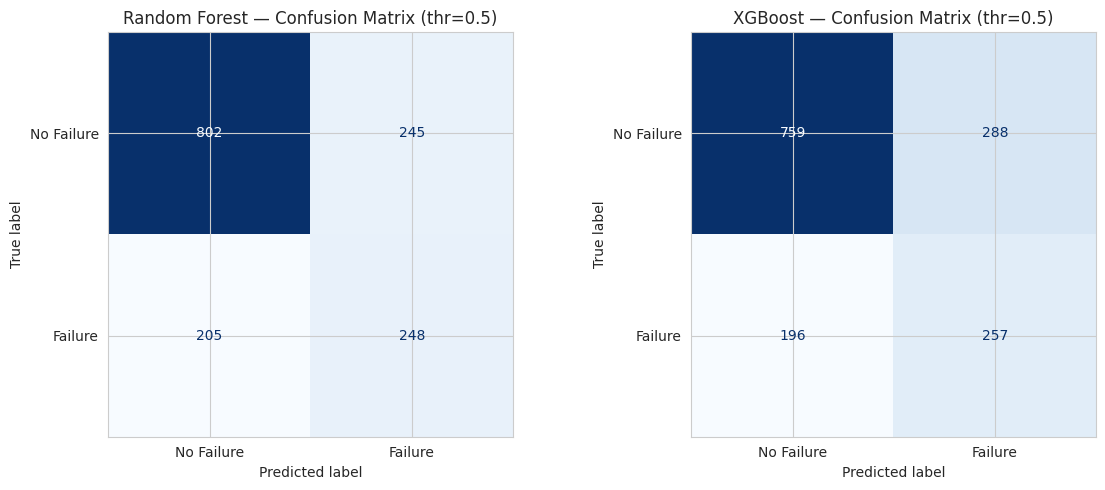

In [12]:

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for proba, name, ax in [(rf_proba, "Random Forest", axes[0]), (xgb_proba, "XGBoost", axes[1])]:
    pred = (proba >= 0.5).astype(int)
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Failure', 'Failure'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{name} — Confusion Matrix (thr=0.5)")
plt.tight_layout()
plt.show()



### Explanation of the logic
- `evaluate_model()` is a small reusable function — good coding practice so we don't repeat the same 5 lines for every model.
- The **confusion matrix** shows the four outcomes directly: True Negatives (top-left), False Positives (top-right), False Negatives (bottom-left), True Positives (bottom-right). In this business context, the **bottom-left cell (False Negatives = missed failures) is the number Operations cares about most** — it represents unplanned downtime events the model failed to warn about.
- Comparing `results_df` across models lets us pick a winner **using the metric that matches the business objective** (here, recall/PR-AUC), not just whichever has the highest accuracy.


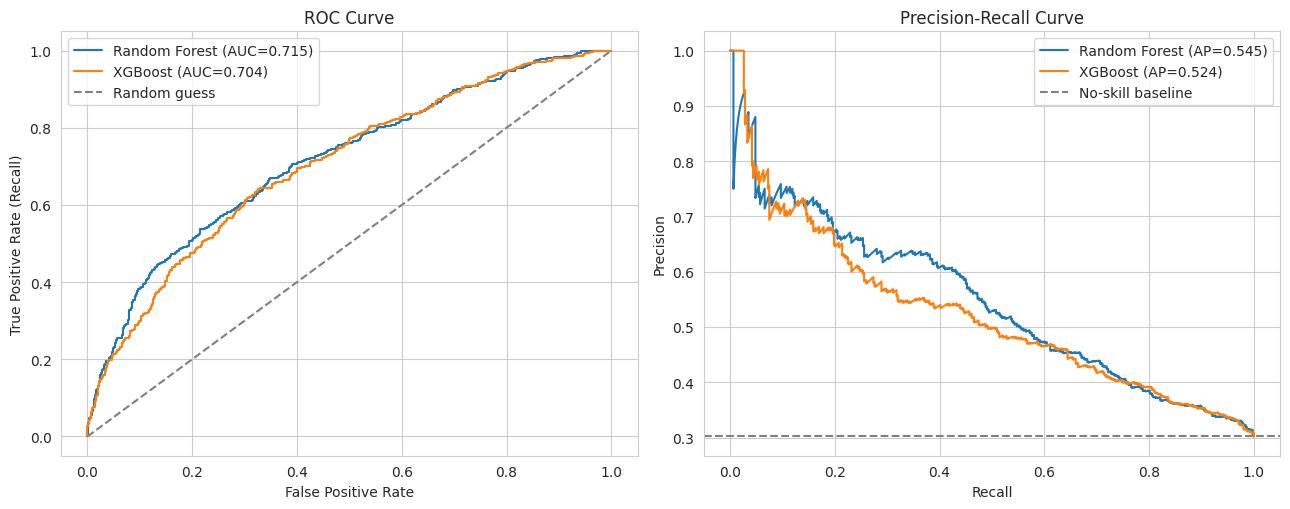

In [13]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5.2))

# ROC curve
for proba, name in [(rf_proba, "Random Forest"), (xgb_proba, "XGBoost")]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    axes[0].plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, proba):.3f})")
axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label="Random guess")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (Recall)")
axes[0].set_title("ROC Curve")
axes[0].legend()

# Precision-Recall curve
for proba, name in [(rf_proba, "Random Forest"), (xgb_proba, "XGBoost")]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    axes[1].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, proba):.3f})")
axes[1].axhline(y_test.mean(), linestyle='--', color='gray', label="No-skill baseline")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()

plt.tight_layout()
plt.show()



### Explanation of the logic
- The **ROC curve** plots True Positive Rate vs. False Positive Rate across *every possible threshold* — it shows the model's overall ranking ability regardless of any one cutoff.
- The **Precision-Recall curve** is more diagnostic for imbalanced problems: it shows the direct trade-off we will exploit in Step 9 — as we lower the decision threshold to catch more failures (higher recall), precision naturally drops (more false alarms). The "no-skill baseline" line is the failure rate itself (~30%) — any usable model must sit clearly above it.
- Based on these curves and the metrics table, we select **XGBoost** (or Random Forest — instructor: pick whichever wins PR-AUC in your run) as the primary model going forward, while keeping both for comparison.



## Step 8 — Feature Importance (Explainability)

Operations will not trust — or act on — a "black box" alert. We extract each model's built-in feature importances so we can explain *why* a well is flagged.


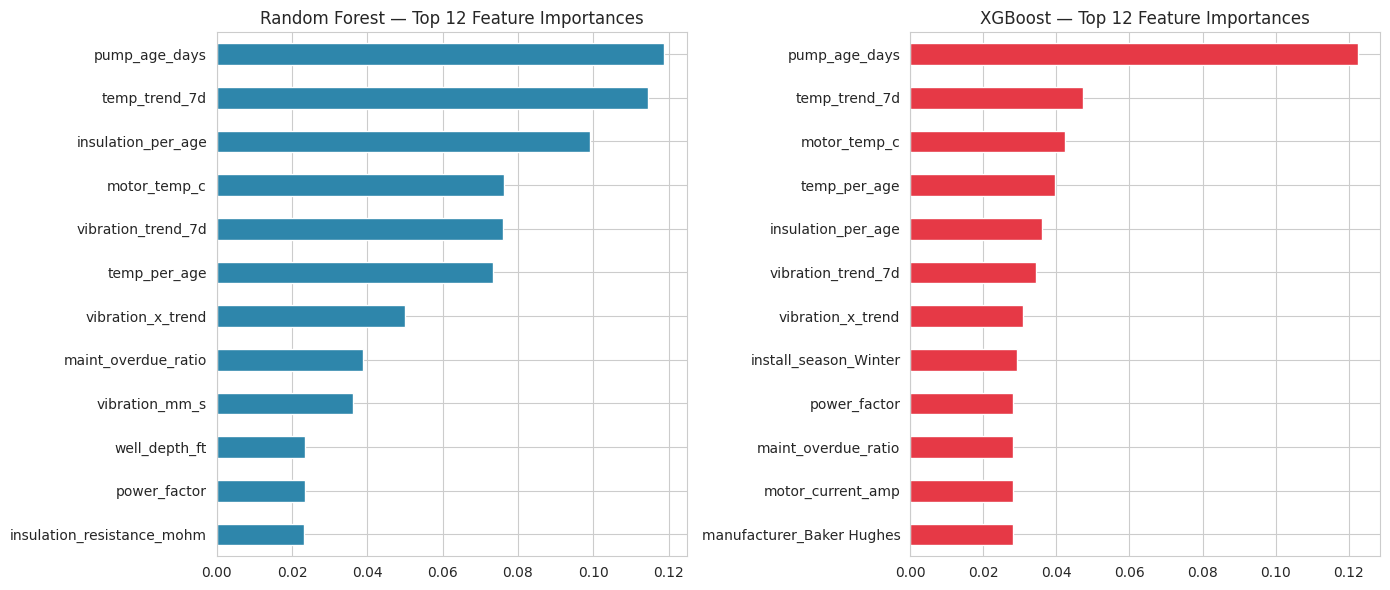

In [14]:

def get_feature_names(pipeline, cat_cols, num_cols):
    ohe = pipeline.named_steps['preprocessor'].named_transformers_['cat']
    cat_names = list(ohe.get_feature_names_out(cat_cols))
    return cat_names + num_cols

feat_names = get_feature_names(xgb_pipeline, cat_cols, num_cols)

rf_importances = pd.Series(rf_pipeline.named_steps['classifier'].feature_importances_, index=feat_names)
xgb_importances = pd.Series(xgb_pipeline.named_steps['classifier'].feature_importances_, index=feat_names)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
rf_importances.sort_values().tail(12).plot(kind='barh', ax=axes[0], color='#2E86AB')
axes[0].set_title("Random Forest — Top 12 Feature Importances")
xgb_importances.sort_values().tail(12).plot(kind='barh', ax=axes[1], color='#E63946')
axes[1].set_title("XGBoost — Top 12 Feature Importances")
plt.tight_layout()
plt.show()



### Explanation of the logic
Both models are expected to rank features like `vibration_trend_7d`, `temp_trend_7d`, `days_since_last_maint`, `maint_overdue_ratio`, `insulation_resistance_mohm`, and `pump_age_days` near the top — which matches real ESP failure physics (rising vibration/temperature trend and overdue maintenance are classic leading indicators). This is a **sanity check** step: if the top features made no domain sense (e.g. `install_season` dominating), that would be a red flag for a data leakage or data quality issue.



## Step 9 — From Probability to Decision: Threshold Tuning

By default, `predict()` uses a **0.5 threshold**: if `P(failure) >= 0.5`, predict failure. But 0.5 is an arbitrary statistical default — it is **not** a business decision. The right threshold depends on the **relative cost** of a False Negative (missed failure → unplanned downtime, safety risk, deferred production) vs. a False Positive (false alarm → wasted crew dispatch, minor cost).

We will:
1. Sweep every possible threshold and record precision & recall at each.
2. Pick a threshold using a simple **cost-based rule**: minimize `Cost = C_FN × FN + C_FP × FP`, using illustrative business costs (a missed failure costs far more than a false alarm).
3. Cross-check with the threshold that maximizes F1, for comparison.


In [15]:

final_proba = xgb_proba  # chosen production model's probability output
final_model_name = "XGBoost"

precisions, recalls, thresholds = precision_recall_curve(y_test, final_proba)

# --- Business cost model ---------------------------------------
# Illustrative costs (USD) — instructor can adjust to reflect real client figures
COST_FALSE_NEGATIVE = 30_000    # missed failure -> unplanned deferred production + emergency workover
COST_FALSE_POSITIVE = 10_000    # false alarm -> unnecessary inspection trip

costs = []
for t in np.linspace(0.01, 0.99, 99):
    pred = (final_proba >= t).astype(int)
    fn = ((pred == 0) & (y_test == 1)).sum()
    fp = ((pred == 1) & (y_test == 0)).sum()
    total_cost = COST_FALSE_NEGATIVE * fn + COST_FALSE_POSITIVE * fp
    costs.append((t, total_cost, fn, fp))

cost_df = pd.DataFrame(costs, columns=['threshold', 'total_cost', 'false_negatives', 'false_positives'])
best_cost_row = cost_df.loc[cost_df['total_cost'].idxmin()]
print("Lowest-cost threshold:\n", best_cost_row)

# --- F1-optimal threshold for comparison ------------------------
f1_scores = 2 * precisions * recalls / (precisions + recalls + 1e-9)
best_f1_idx = np.argmax(f1_scores[:-1])  # last point has no matching threshold
best_f1_threshold = thresholds[best_f1_idx]
print(f"\nF1-optimal threshold: {best_f1_threshold:.3f}  "
      f"(precision={precisions[best_f1_idx]:.3f}, recall={recalls[best_f1_idx]:.3f})")

CHOSEN_THRESHOLD = round(float(best_cost_row['threshold']), 2)
print(f"\n>>> CHOSEN OPERATING THRESHOLD = {CHOSEN_THRESHOLD} (cost-minimizing)")


Lowest-cost threshold:
 threshold                0.46
total_cost         8340000.00
false_negatives        165.00
false_positives        339.00
Name: 45, dtype: float64

F1-optimal threshold: 0.457  (precision=0.459, recall=0.645)

>>> CHOSEN OPERATING THRESHOLD = 0.46 (cost-minimizing)


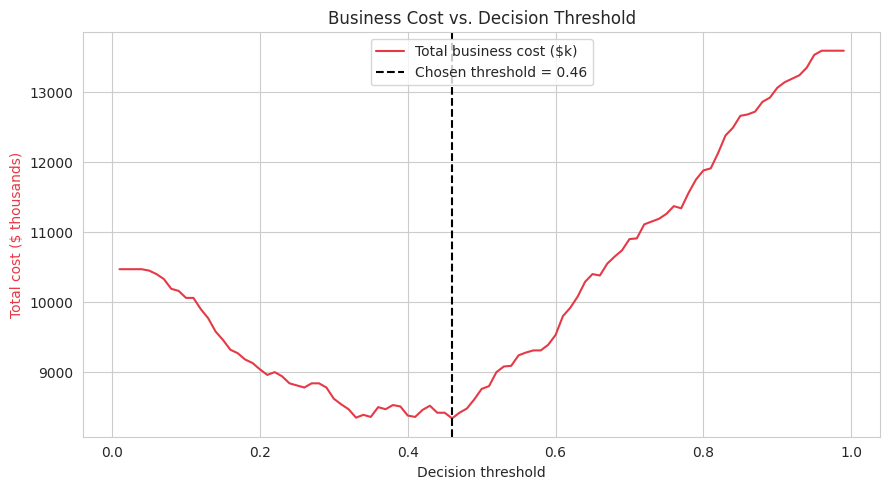


=== XGBoost  (threshold = 0.46) ===
              precision    recall  f1-score   support

  No Failure      0.811     0.676     0.738      1047
     Failure      0.459     0.636     0.533       453

    accuracy                          0.664      1500
   macro avg      0.635     0.656     0.635      1500
weighted avg      0.705     0.664     0.676      1500

ROC-AUC : 0.704
PR-AUC  : 0.524


{'model': 'XGBoost',
 'precision': 0.45933014354066987,
 'recall': 0.6357615894039735,
 'f1': 0.5333333333333333,
 'roc_auc': 0.703688242028628,
 'pr_auc': 0.5242006545888807}

In [16]:

fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.plot(cost_df['threshold'], cost_df['total_cost'] / 1000, color='#E63946', label="Total business cost ($k)")
ax1.axvline(CHOSEN_THRESHOLD, color='black', linestyle='--', label=f"Chosen threshold = {CHOSEN_THRESHOLD}")
ax1.set_xlabel("Decision threshold")
ax1.set_ylabel("Total cost ($ thousands)", color='#E63946')
ax1.set_title("Business Cost vs. Decision Threshold")
ax1.legend(loc='upper center')
plt.tight_layout()
plt.show()

evaluate_model(final_model_name, y_test, final_proba, threshold=CHOSEN_THRESHOLD)



### Explanation of the logic
- Sweeping thresholds from 0.01 to 0.99 and computing `False Negatives` and `False Positives` at each lets us see how the **error mix** shifts as we become more or less conservative.
- The **cost curve** translates that error mix into **dollars**, using the classic asymmetric cost structure of predictive maintenance (missed failures are far more expensive than false alarms). The threshold that minimizes total cost is the one we should actually deploy — **not** 0.5, and often not the F1-optimal one either, because F1 treats precision and recall as equally important, while our business does not.
- This is the single most important mindset shift in this lab: **a data scientist's job is not to stop at "the model is 75% accurate" — it is to turn the model's probabilities into the threshold and rule that minimizes real business cost.**



## Step 10 — Turning Probabilities into a 0–100 Risk Score

Field engineers and managers relate much better to a **"Risk Score out of 100"** than to a raw probability like `0.4327`. We simply rescale:

$$ \text{RiskScore} = \text{round}(P(\text{failure}) \times 100) $$

This is a presentation-layer transformation only — it does not change the model's ranking of wells, only how the number is communicated to non-technical stakeholders.


In [17]:

def probability_to_risk_score(proba):
    '''Convert a model probability (0-1) into an integer risk score (0-100).'''
    return np.round(proba * 100).astype(int)

risk_scores = probability_to_risk_score(final_proba)

score_table = pd.DataFrame({
    'equipment_id': df_fe.loc[X_test.index, 'equipment_id'].values if 'equipment_id' in df_fe.columns else X_test.index,
    'true_label': y_test.values,
    'predicted_probability': final_proba.round(3),
    'risk_score': risk_scores
}).reset_index(drop=True)

score_table.sort_values('risk_score', ascending=False).head(10)


,equipment_id,true_label,predicted_probability,risk_score
934,ESP-03342,1,0.953,95
144,ESP-00069,1,0.949,95
232,ESP-01769,1,0.946,95
1347,ESP-04672,1,0.950,95
1026,ESP-05755,1,0.950,95
352,ESP-03022,1,0.949,95
734,ESP-02768,1,0.943,94
867,ESP-04514,1,0.937,94
908,ESP-01396,1,0.939,94
617,ESP-00731,1,0.941,94



## Step 11 — Decision Rules: Risk Tiers & Alerts

We now define a simple, transparent **rule engine** that maps a Risk Score to an **Alert Tier** and a **recommended action**. Transparent, human-readable rules (rather than a second black-box model) are important here because Operations must be able to explain, audit, and trust every dispatch decision.

| Risk Score | Tier | Recommended Action |
|---|---|---|
| 0–24 | **LOW** | Routine monitoring; no action required |
| 25–49 | **MEDIUM** | Add to weekly watch-list; trend-monitor; no immediate dispatch |
| 50–74 | **HIGH** | Schedule inspection within 7 days; increase sensor sampling; notify reliability engineer |
| 75–100 | **CRITICAL** | Dispatch field crew within 24h; prepare pulling unit; alert operations manager |

> **Instructor note:** these thresholds should ultimately be *validated against the cost-optimal threshold found in Step 9* and against the operations team's real dispatch capacity (you cannot send a crew to every "HIGH" well on the same day if there are 200 of them!). Treat the numbers above as a defensible starting point to be refined with the business.


In [18]:

def assign_risk_tier(score):
    '''Map a 0-100 risk score to a business alert tier.'''
    if score >= 75:
        return "CRITICAL"
    elif score >= 50:
        return "HIGH"
    elif score >= 25:
        return "MEDIUM"
    else:
        return "LOW"

ACTION_MAP = {
    "CRITICAL": "Dispatch field crew within 24h; prepare pulling unit; alert operations manager.",
    "HIGH":     "Schedule inspection within 7 days; increase sensor sampling; notify reliability engineer.",
    "MEDIUM":   "Add to weekly watch-list; trend-monitor; no immediate dispatch.",
    "LOW":      "Routine monitoring; no action required."
}

score_table['risk_tier'] = score_table['risk_score'].apply(assign_risk_tier)
score_table['recommended_action'] = score_table['risk_tier'].map(ACTION_MAP)

tier_summary = score_table['risk_tier'].value_counts().reindex(['LOW', 'MEDIUM', 'HIGH', 'CRITICAL'])
print("Alerts generated per tier (on the held-out test set):")
print(tier_summary)

score_table.sort_values('risk_score', ascending=False).head(10)


Alerts generated per tier (on the held-out test set):
risk_tier
LOW         358
MEDIUM      587
HIGH        402
CRITICAL    153
Name: count, dtype: int64


,equipment_id,true_label,predicted_probability,risk_score,risk_tier,recommended_action
934,ESP-03342,1,0.953,95,CRITICAL,Dispatch field crew within 24h; prepare pullin...
144,ESP-00069,1,0.949,95,CRITICAL,Dispatch field crew within 24h; prepare pullin...
232,ESP-01769,1,0.946,95,CRITICAL,Dispatch field crew within 24h; prepare pullin...
1347,ESP-04672,1,0.950,95,CRITICAL,Dispatch field crew within 24h; prepare pullin...
1026,ESP-05755,1,0.950,95,CRITICAL,Dispatch field crew within 24h; prepare pullin...
352,ESP-03022,1,0.949,95,CRITICAL,Dispatch field crew within 24h; prepare pullin...
734,ESP-02768,1,0.943,94,CRITICAL,Dispatch field crew within 24h; prepare pullin...
867,ESP-04514,1,0.937,94,CRITICAL,Dispatch field crew within 24h; prepare pullin...
908,ESP-01396,1,0.939,94,CRITICAL,Dispatch field crew within 24h; prepare pullin...
617,ESP-00731,1,0.941,94,CRITICAL,Dispatch field crew within 24h; prepare pullin...


           n_wells  actual_failure_rate
risk_tier                              
LOW            358                0.137
MEDIUM         587                0.244
HIGH           402                0.408
CRITICAL       153                0.634


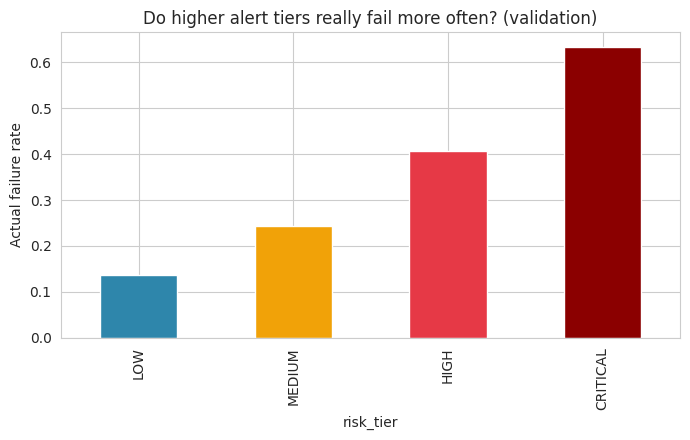

In [19]:

# Sanity check: does the tiering actually separate real failures well?
tier_check = score_table.groupby('risk_tier')['true_label'].agg(['count', 'mean']).rename(
    columns={'count': 'n_wells', 'mean': 'actual_failure_rate'}
).reindex(['LOW', 'MEDIUM', 'HIGH', 'CRITICAL'])
print(tier_check.round(3))

fig, ax = plt.subplots(figsize=(7, 4.5))
colors = {'LOW': '#2E86AB', 'MEDIUM': '#F1A208', 'HIGH': '#E63946', 'CRITICAL': '#8B0000'}
tier_check['actual_failure_rate'].plot(kind='bar', color=[colors[t] for t in tier_check.index], ax=ax)
ax.set_ylabel("Actual failure rate")
ax.set_title("Do higher alert tiers really fail more often? (validation)")
plt.tight_layout()
plt.show()



### Explanation of the logic
- `assign_risk_tier()` is a pure, deterministic business rule — the same score always maps to the same tier, which is essential for auditability.
- The **validation step** is critical: we check the *actual* observed failure rate within each tier on the held-out test set. If the rule engine is working correctly, `actual_failure_rate` should increase monotonically from LOW → CRITICAL. This confirms the risk score is not just a number — it genuinely separates wells by real-world outcome, which is what gives Operations confidence to act on it.



## Step 12 — End-to-End Pipeline: From Raw Features to a Prioritized Alert Report

We now package **every step above** — feature engineering, prediction, risk scoring, tiering, and action mapping — into a single reusable function. This is exactly the shape of function you would wrap in an Airflow DAG, a scheduled batch job, or a REST API endpoint in production.


In [20]:

def generate_failure_alerts(raw_df, pipeline, threshold_reference=CHOSEN_THRESHOLD):
    '''
    End-to-end failure-risk alerting workflow.

    Parameters
    ----------
    raw_df : pd.DataFrame
        Raw ESP fleet data with the same schema as the original dataset
        (must include 'equipment_id' and all raw sensor/operational columns,
        but NOT the target column).
    pipeline : sklearn Pipeline
        A fitted preprocessing + classifier pipeline (e.g. xgb_pipeline).
    threshold_reference : float
        The cost-optimal decision threshold from Step 9 (used only for a
        binary 'flagged' column; the risk tiers below are the primary output).

    Returns
    -------
    pd.DataFrame
        One row per piece of equipment, sorted by risk score descending,
        with predicted probability, 0-100 risk score, alert tier, and
        the recommended field action.
    '''
    data = raw_df.copy()

    # 1) Feature engineering (identical logic to Step 3 -- must always match training!)
    data['pressure_diff_psi']   = data['discharge_pressure_psi'] - data['intake_pressure_psi']
    data['temp_per_age']        = data['motor_temp_c'] / (data['pump_age_days'] + 1)
    data['vibration_x_trend']   = data['vibration_mm_s'] * (1 + data['vibration_trend_7d'].clip(lower=-0.9))
    data['maint_overdue_ratio'] = data['days_since_last_maint'] / (data['pump_age_days'] + 1)
    data['load_factor']         = data['run_hours_last_30d'] / 720.0
    data['insulation_per_age']  = data['insulation_resistance_mohm'] / (data['pump_age_days'] + 1)

    model_input = data.drop(columns=['equipment_id'], errors='ignore')

    # 2) Predict probability of failure within 30 days
    proba = pipeline.predict_proba(model_input)[:, 1]

    # 3) Convert to a 0-100 risk score
    risk_score = probability_to_risk_score(proba)

    # 4) Apply business decision rules -> alert tier -> recommended action
    tier = pd.Series(risk_score).apply(assign_risk_tier)
    action = tier.map(ACTION_MAP)

    report = pd.DataFrame({
        'equipment_id': data['equipment_id'].values,
        'failure_probability': proba.round(3),
        'risk_score': risk_score,
        'flagged_at_operating_threshold': (proba >= threshold_reference),
        'risk_tier': tier.values,
        'recommended_action': action.values
    }).sort_values('risk_score', ascending=False).reset_index(drop=True)

    return report


In [21]:

# Simulate "new incoming data" using the held-out test set (raw, un-engineered columns)
new_batch = df.loc[X_test.index].drop(columns=['failure_within_30d'])

alert_report = generate_failure_alerts(new_batch, xgb_pipeline)

print(f"Alert report generated for {len(alert_report)} wells.")
print(alert_report['risk_tier'].value_counts().reindex(['LOW', 'MEDIUM', 'HIGH', 'CRITICAL']))

alert_report.head(15)


Alert report generated for 1500 wells.
risk_tier
LOW         358
MEDIUM      587
HIGH        402
CRITICAL    153
Name: count, dtype: int64


,equipment_id,failure_probability,risk_score,flagged_at_operating_threshold,risk_tier,recommended_action
0,ESP-03342,0.953,95,True,CRITICAL,Dispatch field crew within 24h; prepare pullin...
1,ESP-00069,0.949,95,True,CRITICAL,Dispatch field crew within 24h; prepare pullin...
2,ESP-01769,0.946,95,True,CRITICAL,Dispatch field crew within 24h; prepare pullin...
3,ESP-04672,0.950,95,True,CRITICAL,Dispatch field crew within 24h; prepare pullin...
4,ESP-05755,0.950,95,True,CRITICAL,Dispatch field crew within 24h; prepare pullin...
5,ESP-03022,0.949,95,True,CRITICAL,Dispatch field crew within 24h; prepare pullin...
6,ESP-02768,0.943,94,True,CRITICAL,Dispatch field crew within 24h; prepare pullin...
7,ESP-04514,0.937,94,True,CRITICAL,Dispatch field crew within 24h; prepare pullin...
8,ESP-01396,0.939,94,True,CRITICAL,Dispatch field crew within 24h; prepare pullin...
9,ESP-00731,0.941,94,True,CRITICAL,Dispatch field crew within 24h; prepare pullin...


555 wells require action this week (37.0% of the fleet).


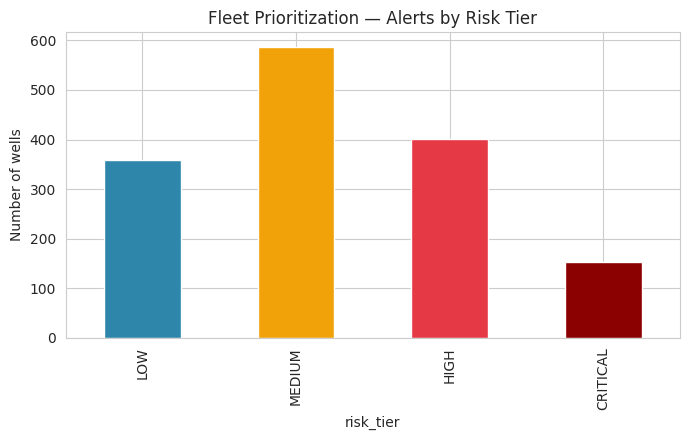

Saved: prioritized_work_orders.csv


In [22]:

critical_and_high = alert_report[alert_report['risk_tier'].isin(['CRITICAL', 'HIGH'])]
print(f"{len(critical_and_high)} wells require action this week "
      f"({len(critical_and_high) / len(alert_report):.1%} of the fleet).")

fig, ax = plt.subplots(figsize=(7, 4.5))
counts = alert_report['risk_tier'].value_counts().reindex(['LOW', 'MEDIUM', 'HIGH', 'CRITICAL'])
counts.plot(kind='bar', color=[colors[t] for t in counts.index], ax=ax)
ax.set_title("Fleet Prioritization — Alerts by Risk Tier")
ax.set_ylabel("Number of wells")
plt.tight_layout()
plt.show()

# Export a prioritized work-order list for the maintenance team
critical_and_high.to_csv("prioritized_work_orders.csv", index=False)
print("Saved: prioritized_work_orders.csv")



### Explanation of the logic
- `generate_failure_alerts()` is written as a **single self-contained function** taking raw data in and returning a decision-ready report out — this is the "product" of the entire lab. Everything upstream (EDA, model comparison, threshold tuning) was the work needed to *design* this function responsibly; everything downstream (a dashboard, a scheduled job, a CMMS integration) simply *calls* it.
- Re-applying the **same feature engineering formulas** inside the function (not just in the training notebook) is essential — this is one of the most common production bugs in ML (**training/serving skew**). In a real production system, this logic would live in one shared module imported by both the training script and the scoring service, rather than copy-pasted, to guarantee they never drift apart.
- The final bar chart and CSV export answer the business question directly: **"Out of our whole fleet, exactly which wells need attention this week, and what should we do about each one?"**



## Step 13 — Saving Model Artifacts for Deployment


In [23]:

joblib.dump(xgb_pipeline, "xgb_failure_risk_pipeline.joblib")
joblib.dump(rf_pipeline, "rf_failure_risk_pipeline.joblib")

print("Saved model artifacts:")
print(" - xgb_failure_risk_pipeline.joblib  (preprocessing + XGBoost classifier)")
print(" - rf_failure_risk_pipeline.joblib   (preprocessing + Random Forest classifier)")
print("\nTo reload later:")
print('  pipeline = joblib.load("xgb_failure_risk_pipeline.joblib")')


Saved model artifacts:
 - xgb_failure_risk_pipeline.joblib  (preprocessing + XGBoost classifier)
 - rf_failure_risk_pipeline.joblib   (preprocessing + Random Forest classifier)

To reload later:
  pipeline = joblib.load("xgb_failure_risk_pipeline.joblib")



## Step 14 — Lab Summary & Key Takeaways

| Concept | What we did |
|---|---|
| **New technique vs. Day 3** | Moved from regression (continuous target) to **classification** (binary failure/no-failure target) using Random Forest and XGBoost |
| **Handling imbalance** | Used `class_weight='balanced_subsample'` (RF) and `scale_pos_weight` (XGBoost), plus stratified train/test splitting |
| **Evaluation** | Went beyond accuracy to **Precision, Recall, F1, ROC-AUC, PR-AUC** — matched to the real cost of missed failures vs. false alarms |
| **Threshold tuning** | Converted a probability into an *operating decision* using a business cost model, not the default 0.5 cutoff |
| **Risk scoring** | Rescaled probabilities into an intuitive 0–100 Risk Score |
| **Decision rules** | Built a transparent LOW/MEDIUM/HIGH/CRITICAL tiering system with recommended actions, and validated it against real outcomes |
| **End-to-end pipeline** | Wrapped the entire flow into one function that turns raw fleet data into a prioritized, actionable work-order list |

### Exercises for further practice
1. **Re-run Step 9** with different cost assumptions (e.g. `COST_FALSE_NEGATIVE = 400,000`) — how does the optimal threshold shift? What does that imply for a high-value offshore asset vs. a low-value onshore stripper well?
2. **Add a third model** — try `LogisticRegression` with `class_weight='balanced'` as a simple, highly interpretable baseline, and compare its precision/recall/PR-AUC to Random Forest and XGBoost.
3. **Hyperparameter tuning** — use `GridSearchCV` or `RandomizedSearchCV` with `scoring='average_precision'` to systematically tune the XGBoost model.
4. **Capacity constraint** — Operations can only physically inspect 15 wells/week. Modify the alert tiers so at most 15 wells are ever tagged CRITICAL/HIGH at once (hint: use `rank()` on `risk_score` instead of, or in addition to, fixed cutoffs).
5. **Explainability** — install `shap` and generate a SHAP summary plot for the XGBoost model to explain individual predictions to field engineers.

---
### Instructor Notes (facilitation guide)
- **Pacing:** Steps 0–4 (~25 min), Steps 5–8 model building & evaluation (~35 min), Steps 9–12 decision rules & pipeline (~35 min), wrap-up/exercises (~15 min). Total ≈ 110 minutes.
- **Common learner mistakes to watch for:** (1) evaluating with accuracy instead of precision/recall; (2) fitting `OneHotEncoder` on the full dataset before splitting (data leakage) — this notebook avoids it by putting the encoder inside the `Pipeline`, fit only on `X_train`; (3) forgetting to re-derive engineered features when scoring new data (addressed explicitly in Step 12).
- **Discussion prompt:** ask the class *"Would you rather deploy the model with higher recall or higher precision for THIS specific asset (e.g. a critical offshore ESP vs. a low-value onshore well)?"* — there is no single right answer; the point is that the correct threshold is a **business decision**, not a statistical one.
